In [ ]:
# ============================================================
# Cell 1. Adjustable parameters
# ============================================================

# ----------------------------
# Basic time parameters
# ----------------------------
tau = 0.96          # RC time constant, s (23 nF * 40 Mohm = 0.96 s)
f = 4.0             # touch frequency, Hz
T = 1 / f           # touch period, s

t_start = 1.0       # first touch time, s
t_stop = 15.6       # last touch time, s
t_end = 20.0        # total simulation time, s
dt = 0.001          # time step, s

# ----------------------------
# Voltage jump parameters
V_first = 1.0       # V, first voltage jump

# Case 1:
V_step = V_first

# Case 2:
# V_n = beta * (V_lim - V_minus)
beta = 0.05

# V_lim is automatically chosen so that the first voltage jump
V_lim = V_first / beta #임의의 값. 물리적인 의미 없음


show_touch_lines = True
line_alpha = 0.12

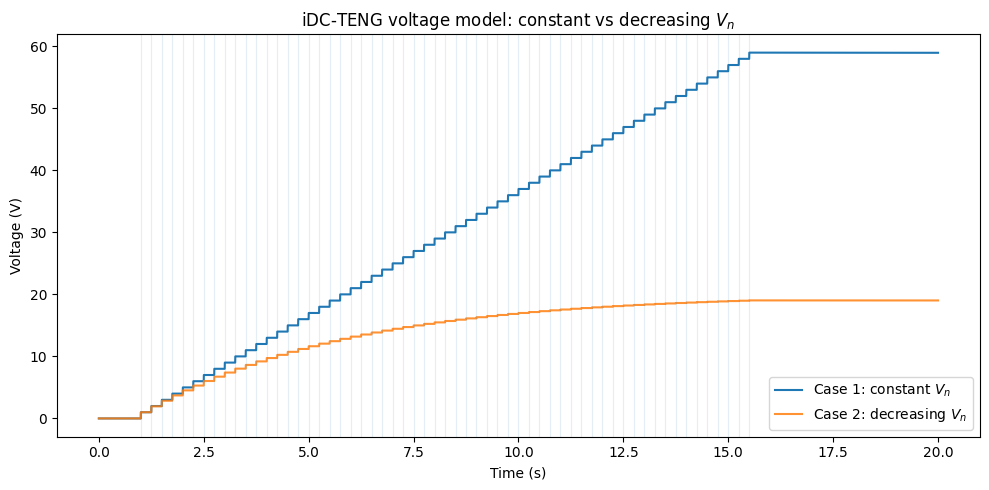

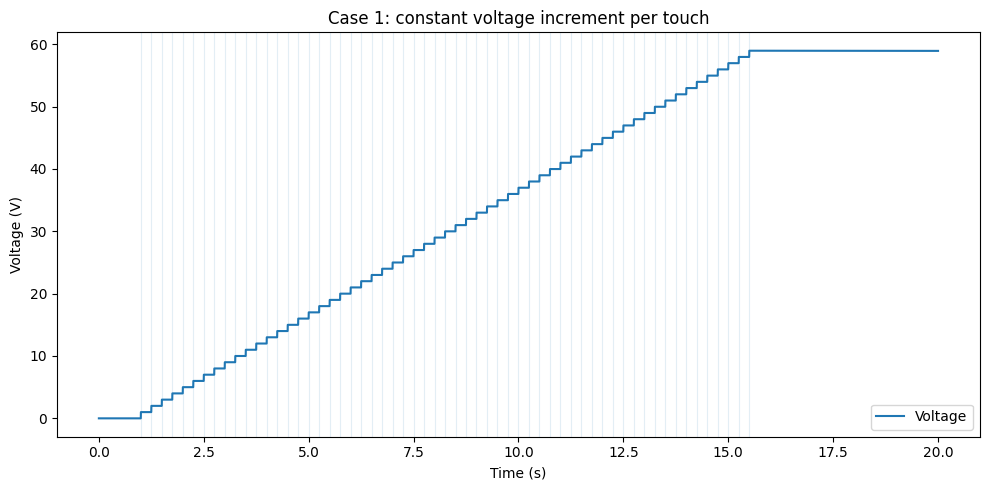

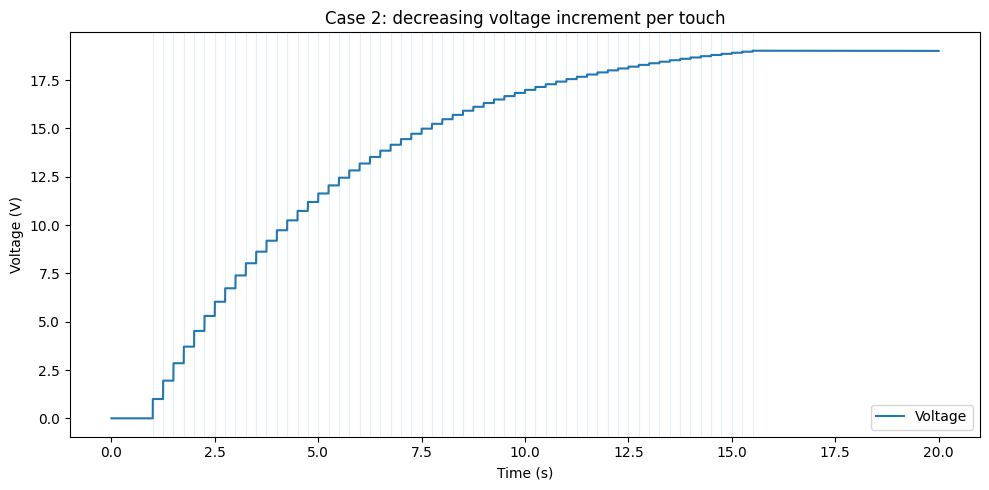

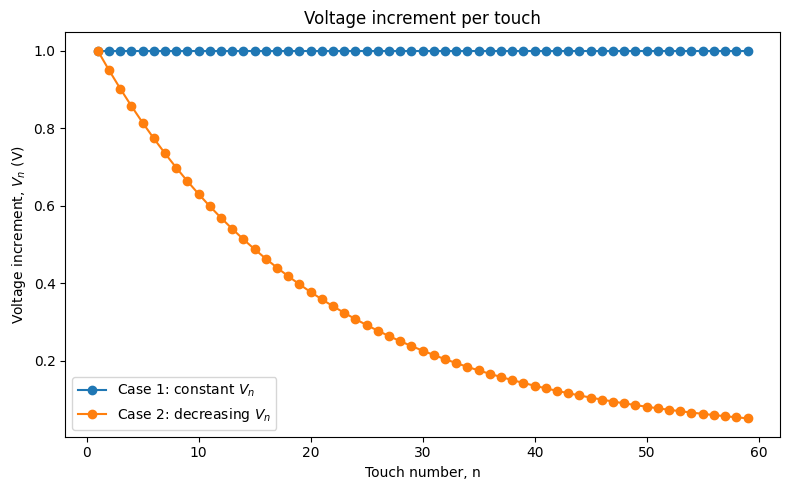

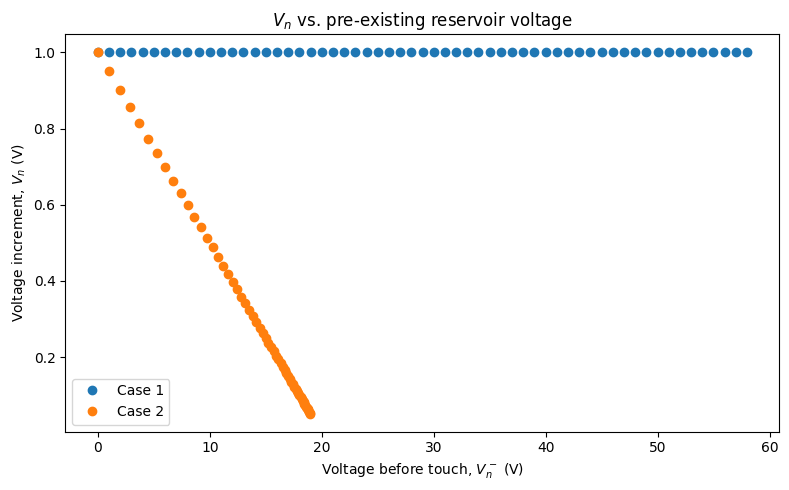

===== Simulation parameters =====
tau = 9600.000 s
f = 4.000 Hz
T = 0.250 s
t_start = 1.000 s
t_stop = 15.600 s
Number of touch events = 59

===== Shared first voltage jump =====
V_first = 1.000 V

===== Case 1: constant V_n =====
V_step = 1.000 V
First V_n = 1.000 V
Second V_n = 1.000 V
Last V_n = 1.000 V
Maximum voltage before touch stop ≈ 58.955 V

===== Case 2: decreasing V_n =====
beta = 0.050
V_lim = 20.000 V
First V_n = 1.000 V
Second V_n = 0.950 V
Last V_n = 0.051 V
Maximum voltage before touch stop ≈ 19.022 V


In [34]:
# ============================================================
# Cell 2. Calculation and plotting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Time array and touch times
# ----------------------------
t = np.arange(0, t_end + dt, dt)
touch_times = np.arange(t_start, t_stop + 1e-12, T)


# ----------------------------
# 2. Case 1: constant V_n
# ----------------------------
def simulate_constant_Vn(t, touch_times, tau, V_step):
    """
    Case 1: Constant voltage increment model.

    Every touch event increases the reservoir voltage by the same amount:
        V_n = V_step

    Between touch events, the voltage decays exponentially:
        V(t) = V0 * exp(-t/tau)
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    Vn_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            V_n = V_step

            current_V += V_n
            V_plus = current_V

            Vn_list.append(V_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(Vn_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 3. Case 2: decreasing V_n
# ----------------------------
def simulate_decreasing_Vn(t, touch_times, tau, beta, V_lim):
    """
    Case 2: Voltage-dependent decreasing increment model.

    The n-th voltage increment is:
        V_n = beta * (V_lim - V_minus)

    where:
        V_minus = reservoir voltage just before the n-th touch

    The first jump is matched to V_first by choosing:
        V_lim = V_first / beta

    Therefore:
        V_1 = beta * V_lim = V_first

    As the reservoir voltage accumulates, V_minus increases,
    and the next voltage increment V_n becomes smaller.
    """
    V = np.zeros_like(t)
    current_V = 0.0
    event_idx = 0
    dt_local = t[1] - t[0]

    Vn_list = []
    Vminus_list = []
    Vplus_list = []

    for i in range(1, len(t)):
        # RC discharge during one time step
        current_V *= np.exp(-dt_local / tau)

        # Apply touch event if it occurs at this time step
        while event_idx < len(touch_times) and t[i-1] < touch_times[event_idx] <= t[i]:
            V_minus = current_V

            # Voltage increment decreases as V_minus approaches V_lim
            V_n = beta * (V_lim - V_minus)

            # Prevent negative voltage increment
            V_n = max(V_n, 0.0)

            current_V += V_n
            V_plus = current_V

            Vn_list.append(V_n)
            Vminus_list.append(V_minus)
            Vplus_list.append(V_plus)

            event_idx += 1

        V[i] = current_V

    return V, np.array(Vn_list), np.array(Vminus_list), np.array(Vplus_list)


# ----------------------------
# 4. Run simulations
# ----------------------------
V_const, Vn_const, Vminus_const, Vplus_const = simulate_constant_Vn(
    t=t,
    touch_times=touch_times,
    tau=tau,
    V_step=V_step
)

V_decr, Vn_decr, Vminus_decr, Vplus_decr = simulate_decreasing_Vn(
    t=t,
    touch_times=touch_times,
    tau=tau,
    beta=beta,
    V_lim=V_lim
)


# ----------------------------
# 5. Plot: comparison of both models
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_const, label="Case 1: constant $V_n$")
plt.plot(t, V_decr, label="Case 2: decreasing $V_n$", alpha=0.85)

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("iDC-TENG voltage model: constant vs decreasing $V_n$")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 6. Plot: Case 1 only
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_const, label="Voltage")

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Case 1: constant voltage increment per touch")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 7. Plot: Case 2 only
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t, V_decr, label="Voltage")

if show_touch_lines:
    for tt in touch_times:
        plt.axvline(tt, alpha=line_alpha, linewidth=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Case 2: decreasing voltage increment per touch")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 8. Plot: V_n trend
# ----------------------------
n_const = np.arange(1, len(Vn_const) + 1)
n_decr = np.arange(1, len(Vn_decr) + 1)

plt.figure(figsize=(8, 5))
plt.plot(n_const, Vn_const, marker="o", label="Case 1: constant $V_n$")
plt.plot(n_decr, Vn_decr, marker="o", label="Case 2: decreasing $V_n$")
plt.xlabel("Touch number, n")
plt.ylabel("Voltage increment, $V_n$ (V)")
plt.title("Voltage increment per touch")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 9. Plot: V_n vs V_minus
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(Vminus_const, Vn_const, marker="o", linestyle="none", label="Case 1")
plt.plot(Vminus_decr, Vn_decr, marker="o", linestyle="none", label="Case 2")
plt.xlabel("Voltage before touch, $V_n^-$ (V)")
plt.ylabel("Voltage increment, $V_n$ (V)")
plt.title("$V_n$ vs. pre-existing reservoir voltage")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# 10. Print useful values
# ----------------------------
print("===== Simulation parameters =====")
print(f"tau = {tau:.3f} s")
print(f"f = {f:.3f} Hz")
print(f"T = {T:.3f} s")
print(f"t_start = {t_start:.3f} s")
print(f"t_stop = {t_stop:.3f} s")
print(f"Number of touch events = {len(touch_times)}")

print("\n===== Shared first voltage jump =====")
print(f"V_first = {V_first:.3f} V")

print("\n===== Case 1: constant V_n =====")
print(f"V_step = {V_step:.3f} V")
print(f"First V_n = {Vn_const[0]:.3f} V")
print(f"Second V_n = {Vn_const[1]:.3f} V")
print(f"Last V_n = {Vn_const[-1]:.3f} V")
print(f"Maximum voltage before touch stop ≈ {np.max(V_const[t < t_stop]):.3f} V")

print("\n===== Case 2: decreasing V_n =====")
print(f"beta = {beta:.3f}")
print(f"V_lim = {V_lim:.3f} V")
print(f"First V_n = {Vn_decr[0]:.3f} V")
print(f"Second V_n = {Vn_decr[1]:.3f} V")
print(f"Last V_n = {Vn_decr[-1]:.3f} V")
print(f"Maximum voltage before touch stop ≈ {np.max(V_decr[t < t_stop]):.3f} V")